In [1]:
#Autoreload so we don't have to restart kernel every time we change source code
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#%matplotlib qt

#Astronomy
import healpy as hp
#My packages

import loader
from constants import data_dir, plt_dir
from constants import SLOPE, OFFSET

# Load data #

In [3]:
"""Load the Zhang and Green 2025 HEALPix dustmaps from the HDF5 file using a custom loader object."""

ZhangGreen = loader.HDF5Loader(data_dir, 'Rv_map_new.h5')
E_map_int_256 = ZhangGreen.load_data(['map_256/E_map_int'])
E_map_int_128 = ZhangGreen.load_data(['map_128/E_map_int'])
E_map_int_64 = ZhangGreen.load_data(['map_64/E_map_int'])
E_map_diff_256 = ZhangGreen.load_data(['map_256/E_map_diff'])
E_map_diff_128 = ZhangGreen.load_data(['map_128/E_map_diff'])
E_map_diff_64 = ZhangGreen.load_data(['map_64/E_map_diff'])
RV_map_int_256 = ZhangGreen.load_data(['map_256/R55_map_int']) * SLOPE + OFFSET
RV_map_combined = ZhangGreen.load_data(['map_combined/R55_map_int']) * SLOPE + OFFSET
all_distances = ZhangGreen.load_data(['distance_bins'])

Loading ['map_256/E_map_int'] from disk into RAM (this happens only once)...
Loading ['map_128/E_map_int'] from disk into RAM (this happens only once)...
Loading ['map_64/E_map_int'] from disk into RAM (this happens only once)...
Loading ['map_256/E_map_diff'] from disk into RAM (this happens only once)...
Loading ['map_128/E_map_diff'] from disk into RAM (this happens only once)...
Loading ['map_64/E_map_diff'] from disk into RAM (this happens only once)...
Loading ['map_256/R55_map_int'] from disk into RAM (this happens only once)...
Loading ['map_combined/R55_map_int'] from disk into RAM (this happens only once)...
Loading ['distance_bins'] from disk into RAM (this happens only once)...


In [4]:
"""Initialize a custom loader object for the stellar catalog.
    Rerunning this cell will initialize a new object, removing cached data from memory."""
catalog = loader.StellarCatalogLoader(data_dir + '/xpparams_v2_zenodo')

In [5]:
"""Load desired columns from Zhang and Green 2025 stellar catalog.
    Requested columns are stored in cache. Columns not in cache are loaded."""

ra_all, dec_all, parallax_all, ext_all, quality_flags_all = catalog.get_columns(['ra', 'dec', 'parallax', 'ext', 'quality_flags'])

Loading ['ra', 'dec', 'parallax', 'ext', 'quality_flags'] from disk into RAM (this happens only once)...


In [8]:
"""Initialize objects that represent the CMB and Galactic fields."""
cmb = loader.Field('CMB', data_dir)
gal = loader.Field('GAL', data_dir)

# Plot maps #

Below are variations of functions to plot the Zhang and Green maps. The maps are in Galactic coordinates and nested order.

You can substitute a different projection (e.g. `hp.mollview`) instead of `orthview`.

In [ ]:
def plot_int_ext_full(ext_map, title, cmb_contour = False, gal_contour = False, save = False, fname = None):
    """Plot full-sky integrated extinction map in Galactic coordinates."""
    hp.orthview(ext_map,
                coord = ['G'],
                rot = [0, 0, 0],
                nest = True,
                title = title,
                cmap = 'inferno',
                badcolor = 'white',
                #min = 0, max = 1.6,
                cbar = False,
                notext = True,
                hold = True)

    # Graticule
    hp.graticule(dpar = 10, dmer = 20)
    # Axes
    ax = plt.gca()
    ax.text(0.0, -1 - 0.06, "Galactic longitude [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-2 - 0.2, 0.0, "Galactic latitude [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$E$ [mag]", fontsize=10, labelpad=10)
    # Contour
    proj = plt.gca().proj
    if cmb_contour:
        xgrid, ygrid = cmb.get_mesh(galactic = True)
        x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
        x_contour = x_contour.reshape(xgrid.shape)
        y_contour = y_contour.reshape(ygrid.shape)
        ax.contour(x_contour, y_contour, cmb.Pw, levels = [0.001], colors = 'white')

    if gal_contour:
        xgrid, ygrid = gal.get_mesh(galactic = True)
        x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
        x_contour = x_contour.reshape(xgrid.shape)
        y_contour = y_contour.reshape(ygrid.shape)
        ax.contour(x_contour, y_contour, gal.Pw, levels = [0.001], colors = 'white')

    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

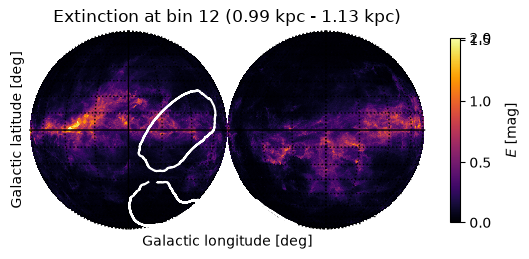

In [9]:
plt_title = f"Extinction at bin 12 ({all_distances[12]:.2f} kpc - {all_distances[13]:.2f} kpc)"
plot_int_ext_full(E_map_int_256[12], plt_title, cmb_contour = True, gal_contour = True)

In [11]:
def plot_int_ext_cmb(ext_map, title, save = False, fname = None):
    """Plot integrated extinction in the CMB field."""
    ra_min, ra_max, dec_min, dec_max = cmb.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(ext_map,
                coord = ['G', 'C'],
                rot = [ra_center, dec_center, 0],
                nest = True,
                half_sky = True,
                title = title,
                cmap = 'inferno',
                badcolor = 'white',
                min = 0, max = 0.12,
                cbar = False,
                notext = True,
                hold = True)
    # Graticule
    hp.graticule(dpar = 10, dmer = 25)

    lon_labels = [50, 25, 0, -25]
    lat_labels = [-70, -60, -50]
    lon0 = 50
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat = True, fontsize = 6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat = True, fontsize = 6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-0.6 - 0.1, 0.0, "Declination [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$ E$ [mag]", fontsize=10, labelpad=10)
    # Contour
    xgrid, ygrid = cmb.get_mesh(galactic = False)
    proj = ax.proj
    x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
    x_contour = x_contour.reshape(xgrid.shape)
    y_contour = y_contour.reshape(ygrid.shape)

    ax.contour(x_contour, y_contour, cmb.Pw, levels = [0.001], colors = 'white')
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

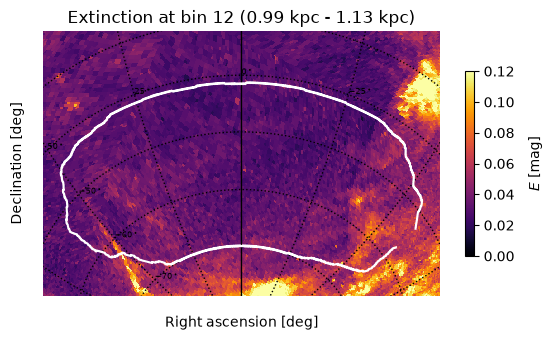

In [12]:
plt_title = f"Extinction at bin 12 ({all_distances[12]:.2f} kpc - {all_distances[13]:.2f} kpc)"
plot_int_ext_cmb(E_map_int_256[12], plt_title)

In [14]:
def plot_int_ext_gal(ext_map, title, save = False, fname = None):
    """Plot integrated extinction map in the Galactic field."""
    ra_min, ra_max, dec_min, dec_max = gal.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(ext_map,
                coord = ['G', 'C'],
                rot = [ra_center, dec_center, 0],
                nest = True,
                half_sky = True,
                title = title,
                cmap = 'inferno',
                badcolor = 'white',
                min = 0, max = 1.6,
                cbar = False,
                notext = True,
                hold = True)
    # Graticule
    hp.graticule(dpar = 10, dmer = 25)
    lon_labels = [260, 235, 210]
    lat_labels = [-40, -50, -60, -70]
    lon0 = 285
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat = True, fontsize = 6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat = True, fontsize = 6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-0.6 - 0.1, 0.0, "Declination [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$ E$ [mag]", fontsize=10, labelpad=10)
    # Contour
    xgrid, ygrid = gal.get_mesh(galactic = False)

    proj = plt.gca().proj
    x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
    x_contour = x_contour.reshape(xgrid.shape)
    y_contour = y_contour.reshape(ygrid.shape)
    ax.contour(x_contour, y_contour, gal.Pw, levels = [0.001], colors = 'white')

    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

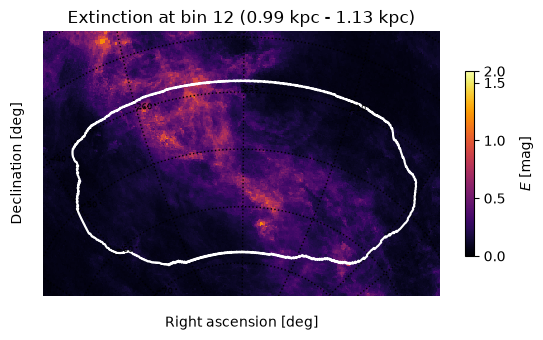

In [15]:
plt_title = f"Extinction at bin 12 ({all_distances[12]:.2f} kpc - {all_distances[13]:.2f} kpc)"
plot_int_ext_gal(E_map_int_256[12], plt_title)

In [17]:
def plot_int_rv_cmb(rv_map, title, save = False, fname = None):
    """Plot integrated R(V) map in the CMB field."""
    ra_min, ra_max, dec_min, dec_max = cmb.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(rv_map,
                coord = ['G', 'C'],
                rot = [ra_center, dec_center, 0],
                nest = True,
                half_sky = True,
                title = title,
                cmap = 'coolwarm_r',
                badcolor = 'white',
                min = 2.5, max = 5.5,
                cbar = False,
                notext = True,
                hold = True)
    # Graticule
    hp.graticule(dpar = 10, dmer = 25)
    lon_labels = [50, 25, 0, -25]
    lat_labels = [-70, -60, -50]
    lon0 = 50
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat = True, fontsize = 6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat = True, fontsize = 6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-0.6 - 0.1, 0.0, "Declination [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$R(V)$ [mag]", fontsize=10, labelpad=10)
    # Contour
    xgrid, ygrid = cmb.get_mesh(galactic = False)

    proj = plt.gca().proj
    x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
    x_contour = x_contour.reshape(xgrid.shape)
    y_contour = y_contour.reshape(ygrid.shape)
    ax.contour(x_contour, y_contour, cmb.Pw, levels = [0.001], colors = 'black')

    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

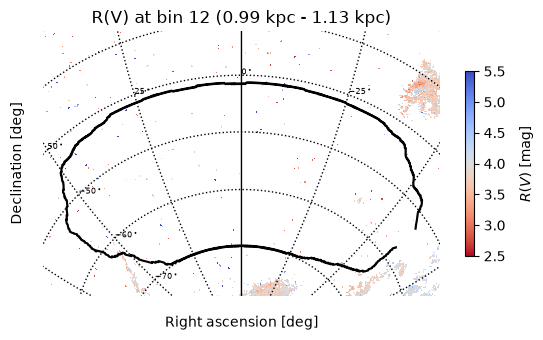

In [18]:
plt_title = f"R(V) at bin 12 ({all_distances[12]:.2f} kpc - {all_distances[13]:.2f} kpc)"
plot_int_rv_cmb(RV_map_int_256[12], plt_title)

In [19]:
def plot_int_rv_gal(rv_map, title, save = False, fname = None):
    """Plot integrated R(V) map in Galactic coordinates."""
    ra_min, ra_max, dec_min, dec_max = gal.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(rv_map,
                coord = ['G', 'C'],
                rot = [ra_center, dec_center, 0],
                nest = True,
                half_sky = True,
                title = title,
                cmap = 'coolwarm_r',
                badcolor = 'white',
                min = 3, max = 5,
                cbar = False,
                notext = True,
                hold = True)
    # Graticule
    hp.graticule(dpar = 10, dmer = 25)
    lon_labels = [260, 235, 210]
    lat_labels = [-40, -50, -60, -70]
    lon0 = 285
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat = True, fontsize = 6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat = True, fontsize = 6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-0.6 - 0.1, 0.0, "Declination [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$R(V)$ [mag]", fontsize=10, labelpad=10)
    # Contour
    xgrid, ygrid = gal.get_mesh(galactic = False)

    proj = plt.gca().proj
    x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
    x_contour = x_contour.reshape(xgrid.shape)
    y_contour = y_contour.reshape(ygrid.shape)
    ax.contour(x_contour, y_contour, gal.Pw, levels = [0.001], colors = 'black')

    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

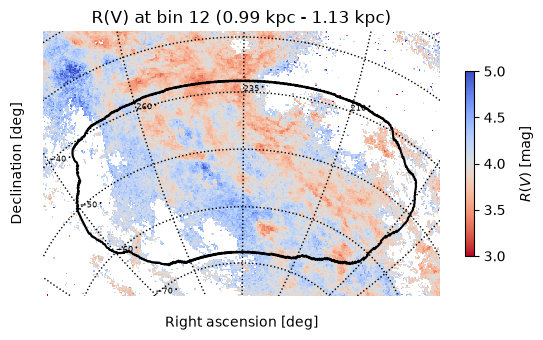

In [20]:
plt_title = f"R(V) at bin 12 ({all_distances[12]:.2f} kpc - {all_distances[13]:.2f} kpc)"
plot_int_rv_gal(RV_map_int_256[12], plt_title)

R(V) maps are blank whenever there is not enough extinction for reliable measurements (E < 0.1 mag or Delta E < 0.1 mag/kpc). For better coverage, I take the furthest non-blank value for each pixel.

In [21]:
#Collates a (M, N) array into a length N array by taking the furthest non-NaN value along the first axis.
def collate(raw_data : np.ndarray) -> np.ndarray:
    if(raw_data.ndim != 2):
       print("Invalid array dimensions (must be 2)")
    else:
        mask = ~np.isnan(raw_data)
        row_indices = np.where(mask.any(axis=0), mask.shape[0] - 1 - np.argmax(mask[::-1, :], axis=0), -1)
        data = np.full(raw_data.shape[1], np.nan)
        valid_pixels = row_indices != -1
        data[valid_pixels] = raw_data[row_indices[valid_pixels], np.arange(raw_data.shape[1])[valid_pixels]]
    return data

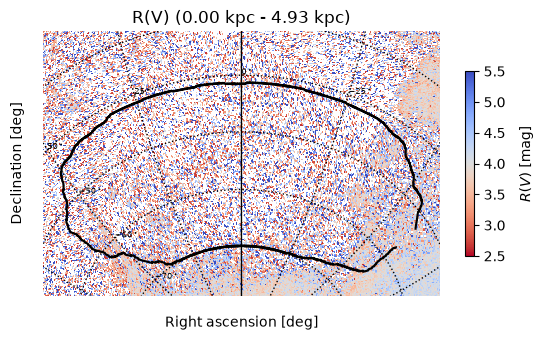

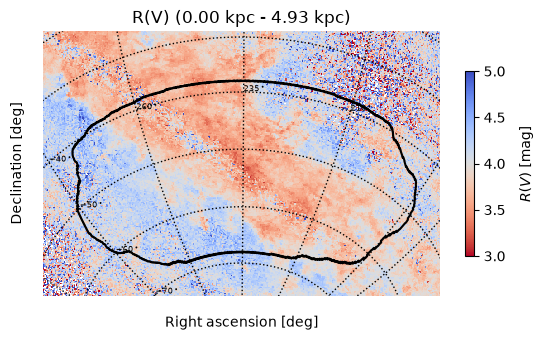

In [22]:
collated_rv = collate(RV_map_int_256)
plt_title = f"R(V) ({all_distances[0]:.2f} kpc - {all_distances[-1]:.2f} kpc)"
plot_int_rv_cmb(collated_rv, plt_title)
plot_int_rv_gal(collated_rv, plt_title)

For even better angular coverage, we can use the combined map, in which pixels take on the value of lower-resolution maps when higher-resolution values are not available.

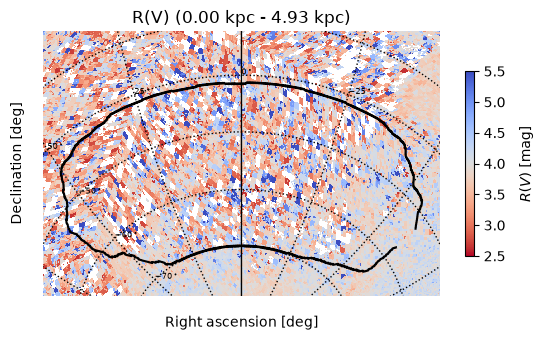

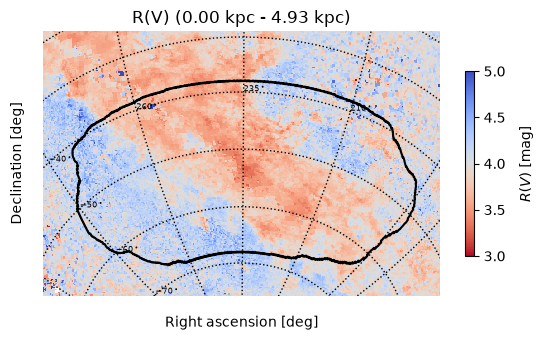

In [23]:
collated_rv = collate(RV_map_combined)
plt_title = f"R(V) ({all_distances[0]:.2f} kpc - {all_distances[-1]:.2f} kpc)"
plot_int_rv_cmb(collated_rv, plt_title)
plot_int_rv_gal(collated_rv, plt_title)